# Assistant budgétaire intelligent & détection d'anomalies de dépenses

**Angle décisionnel** — aider un particulier à (1) **catégoriser
automatiquement** ses dépenses à partir du libellé bancaire, (2) **comprendre**
son comportement de consommation normal, et (3) être **alerté** en cas de
dépense inhabituelle — le tout de façon transparente et personnalisée.

**Données** — aucun jeu ouvert ne combine libellés réalistes, habitudes
par utilisateur, saisonnalité **et** anomalies étiquetées. On **génère** donc
des transactions synthétiques réalistes (Faker + règles), avec une **vérité
terrain** (`category`, `is_anomaly`, `anomaly_type`) pour évaluer honnêtement
chaque brique.

**Plan** : données → catégorisation NLP → comportement normal → détection
d'anomalies → recommandations budgétaires → limites.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from generate import load_raw

df = load_raw()
print(f"{len(df):,} transactions | {df.user.nunique()} utilisateurs | "
      f"{df.date.min().date()} → {df.date.max().date()}")
print(f"anomalies injectées : {df.is_anomaly.sum()} "
      f"({df.is_anomaly.mean()*100:.2f}%)")
df[["date", "user", "label", "amount", "category",
    "is_anomaly", "anomaly_type"]].head(8)

5,903 transactions | 8 utilisateurs | 2024-01-01 → 2025-06-28
anomalies injectées : 160 (2.71%)


,date,user,label,amount,category,is_anomaly,anomaly_type
0,2024-01-02,user_0,CASINO SUPERMARCHE 15,58.53,Groceries,False,none
1,2024-01-03,user_0,LOYER APPARTEMENT,1086.65,Housing,False,none
2,2024-01-03,user_0,CB INTERMARCHE,36.06,Groceries,False,none
3,2024-01-03,user_0,APPLE STORE,1474.80,Shopping,True,wrong_category
4,2024-01-03,user_0,ESSO STATION,69.60,Transport,False,none
5,2024-01-03,user_0,PHARMACIE 12,1.40,Health,False,none
6,2024-01-05,user_0,ABONNEMENT SALLE SPORT,42.69,Leisure,False,none
7,2024-01-05,user_0,LECLERC,43.83,Groceries,False,none


## 1. Des données volontairement réalistes

Les libellés portent du bruit de succursale/ville (« CB CARREFOUR », « UBER
EATS 08 »), les habitudes varient par utilisateur, et quatre familles
d'anomalies sont injectées : **pic de montant**, **achat hors habitude**,
**débit en double** et **rafale de débits**. C'est ce qui rend le problème
non trivial.

In [2]:
print("Catégories :")
display(df.category.value_counts())
print("Types d'anomalies :")
display(df[df.is_anomaly].anomaly_type.value_counts())

Catégories :


category
Groceries      1632
Restaurants    1158
Transport       989
Leisure         809
Shopping        486
Utilities       288
Health          253
Housing         144
Insurance       144
Name: count, dtype: int64

Types d'anomalies :


anomaly_type
frequency_burst    102
duplicate           26
amount_spike        18
wrong_category      14
Name: count, dtype: int64

## 2. Catégorisation automatique (NLP)

Deux approches comparées : **règles** par mots-clés (transparentes mais fragiles)
et **TF-IDF sur n-grammes de caractères + SVM linéaire** (robuste au bruit de
libellé). Les n-grammes de caractères permettent de reconnaître « carrefour »
dans « CB CARREFOUR EXPRESS LYON ».

,method,macro_f1,coverage
0,rules,0.977,1.0
1,tfidf_svm,1.000,1.0


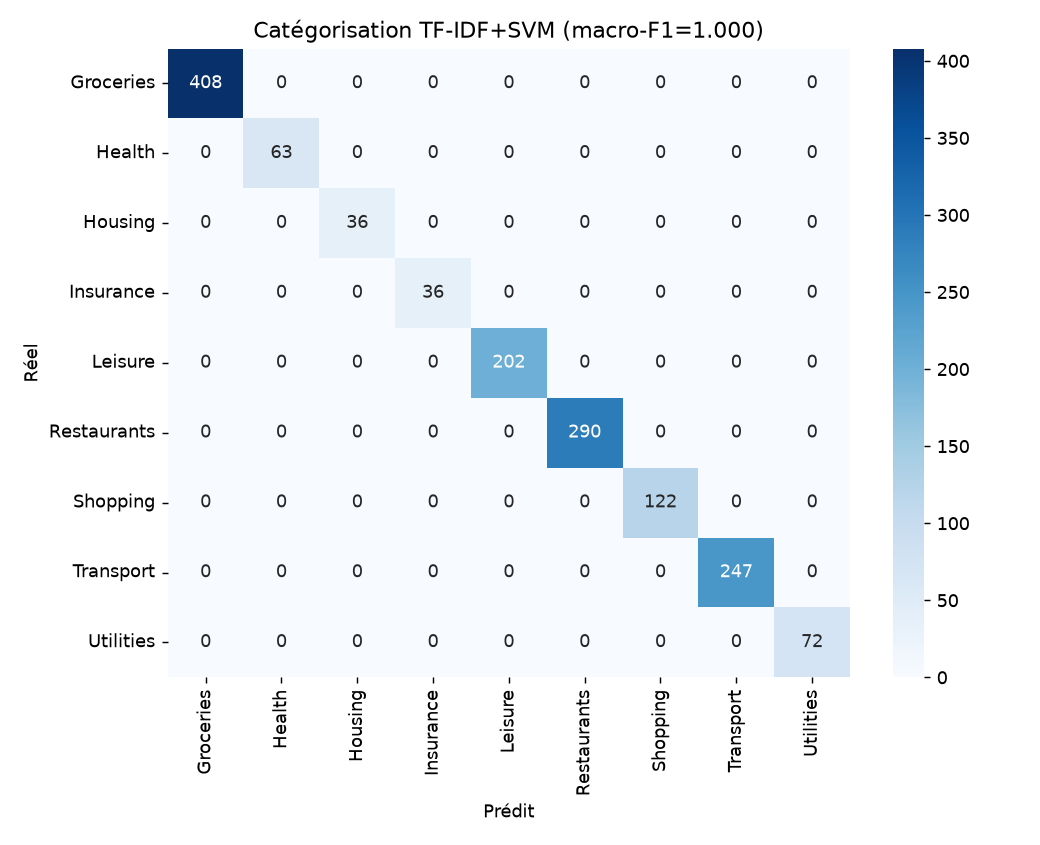

In [3]:
comp = pd.read_csv(ROOT / "reports" / "categorization_comparison.csv")
display(comp.round(3))
display(Image(ROOT / "reports" / "figures" /
              "categorization_confusion.png", width=560))

**Lecture** — le modèle TF-IDF généralise à des libellés **jamais vus** en
entraînement (ex. « SNCF CONNECT » → Transport). Le score très élevé reflète
un vocabulaire de marchands partagé ; le vrai test de robustesse est la
généralisation aux libellés inédits (voir `src/categorize.py`). « Amazon » est
volontairement ambigu (Prime/Shopping) — une ambiguïté réaliste.

## 3. Comportement « normal » personnalisé

Une anomalie est **relative à l'utilisateur** : 300 € est normal pour un loyer,
alarmant pour des courses. On modélise une base robuste par (utilisateur,
catégorie) — médiane et MAD glissantes **causales** (passé uniquement) — et un
**z-score robuste**.

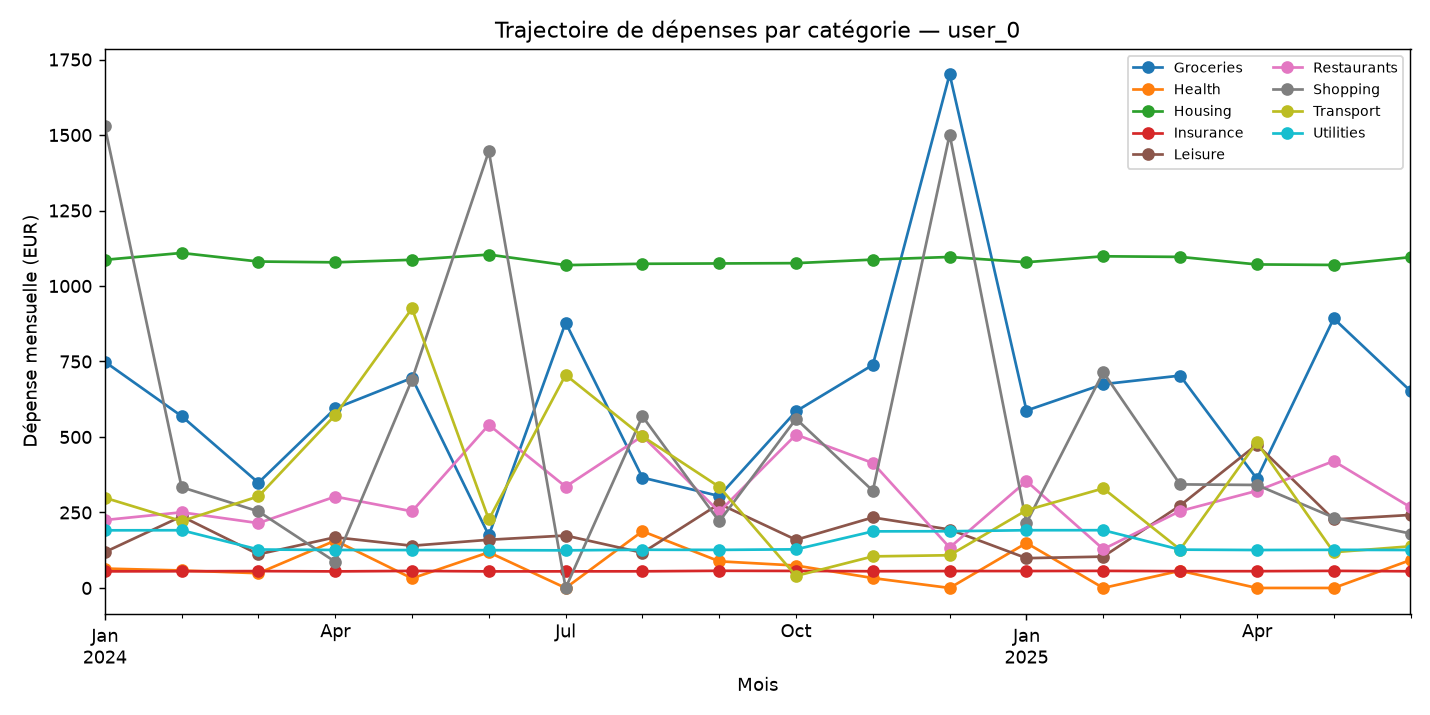

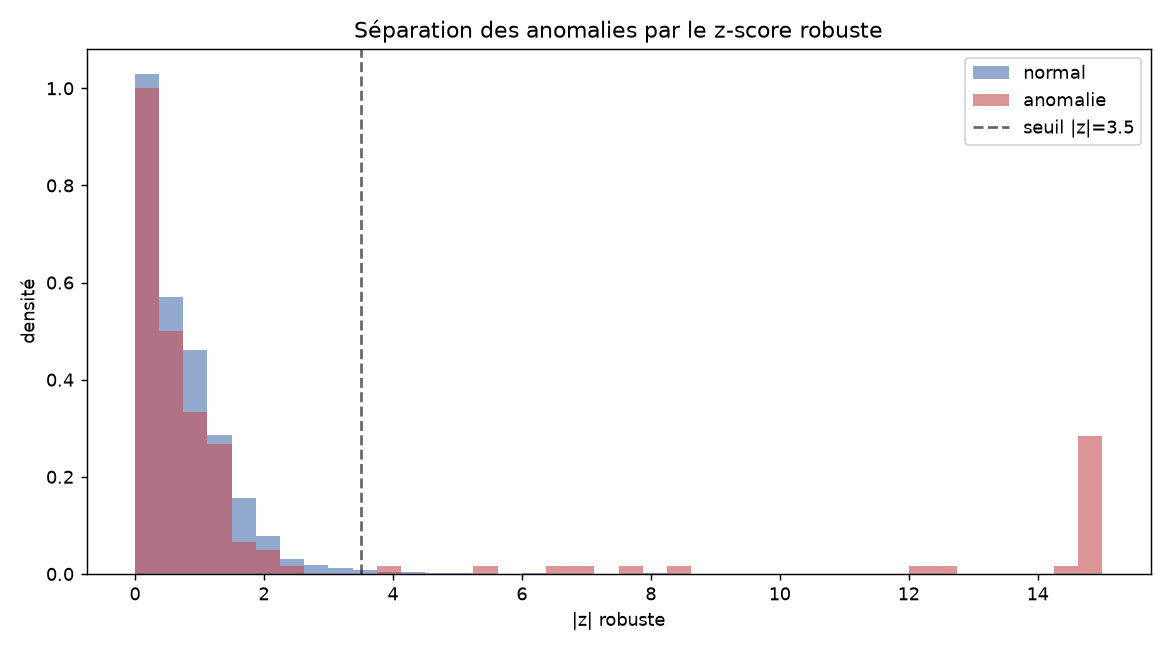

In [4]:
for fig in ["spend_trajectory.png", "zscore_separation.png"]:
    display(Image(ROOT / "reports" / "figures" / fig, width=760))

**Lecture importante** — le z-score sur le montant ne sépare bien que les
anomalies **de montant** (pics, achats hors habitude). Les **doublons** et
**rafales** ont des montants normaux : ils exigent des features de
**fréquence/duplication**. D'où l'approche multivariée au §4.

## 4. Détection d'anomalies — comparaison

Features couvrant les 4 mécanismes (z-score, montant, compteur intra-journalier,
doublon, rareté de catégorie), et trois détecteurs comparés à la vérité terrain :
**règle transparente**, **Isolation Forest**, **DBSCAN**.

,method,PR_AUC,precision,recall,threshold
0,IsolationForest,0.910,0.903,0.875,0.595
1,Rule (z|dup|burst),0.675,0.762,0.881,0.500
2,DBSCAN (noise),0.174,0.929,0.162,0.500


Rappel d'Isolation Forest par type d'anomalie :


,anomaly_type,n,caught,recall
0,amount_spike,18,14,0.78
1,duplicate,26,14,0.54
2,frequency_burst,102,102,1.00
3,wrong_category,14,10,0.71


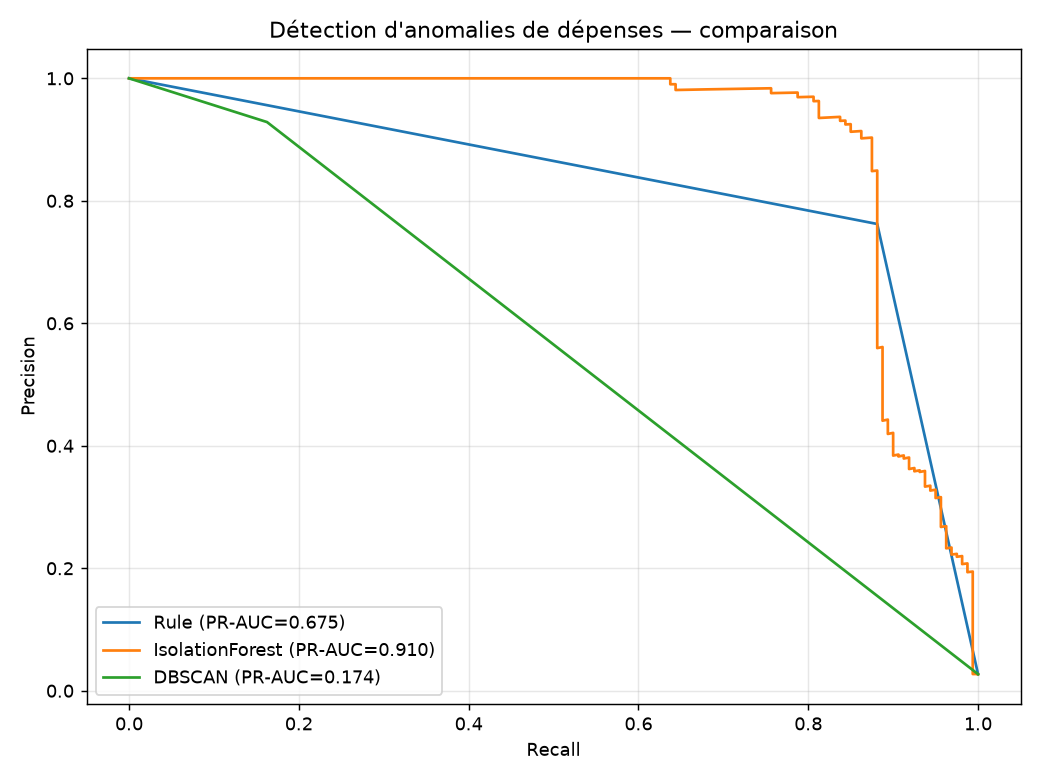

In [5]:
comp = pd.read_csv(ROOT / "reports" / "anomaly_comparison.csv")
by_type = pd.read_csv(ROOT / "reports" / "anomaly_recall_by_type.csv")
display(comp.round(3))
print("Rappel d'Isolation Forest par type d'anomalie :")
display(by_type.round(2))
display(Image(ROOT / "reports" / "figures" / "anomaly_pr_curves.png", width=620))

**Lecture** — **Isolation Forest** l'emporte (PR-AUC 0,91, précision 0,90,
rappel 0,88). Le rappel par type est instructif : **100 %** des rafales, ~78 %
des pics de montant, ~71 % des achats hors habitude, mais seulement ~54 % des
**doublons** — les plus discrets (montant normal, seul le timing trahit).
DBSCAN est peu adapté ici (rappel faible). La règle transparente reste un bon
filet de base.

## 5. Recommandations budgétaires & alertes

Budget mensuel robuste par catégorie (médiane des mois *normaux* + tolérance
MAD), projection fin de mois à partir du dépensé courant, et flux d'alertes
lisible.

Catégories en dépassement projeté :


,user,category,budget,projected,overshoot_pct
0,user_7,Health,65.9,1292.0,1861.8
1,user_5,Shopping,146.3,1920.4,1212.5
2,user_7,Leisure,166.0,1105.5,566.1
3,user_1,Transport,343.9,1112.1,223.4
4,user_2,Shopping,115.0,327.6,184.8
5,user_1,Health,72.4,191.4,164.6
6,user_3,Restaurants,199.4,513.8,157.7
7,user_4,Shopping,178.5,451.3,152.8


Flux d'alertes (extrait) :


,date,user,label,category,amount,alert
0,2024-01-12,user_4,APPLE STORE,Shopping,1834.42,Achat hors habitude
1,2024-11-24,user_7,CB APPLE STORE,Shopping,1804.71,Achat hors habitude
2,2024-11-08,user_3,APPLE STORE PELTIERDAN,Shopping,1803.14,Achat hors habitude
3,2025-03-14,user_3,APPLE STORE CARON,Shopping,1785.97,Achat hors habitude
4,2024-04-26,user_4,APPLE STORE 15,Shopping,1702.74,Achat hors habitude
5,2025-06-23,user_5,APPLE STORE,Shopping,1625.73,Achat hors habitude
6,2024-01-03,user_0,APPLE STORE,Shopping,1474.80,Achat hors habitude
7,2024-08-03,user_1,APPLE STORE JEANBOURG,Shopping,1354.92,Achat hors habitude


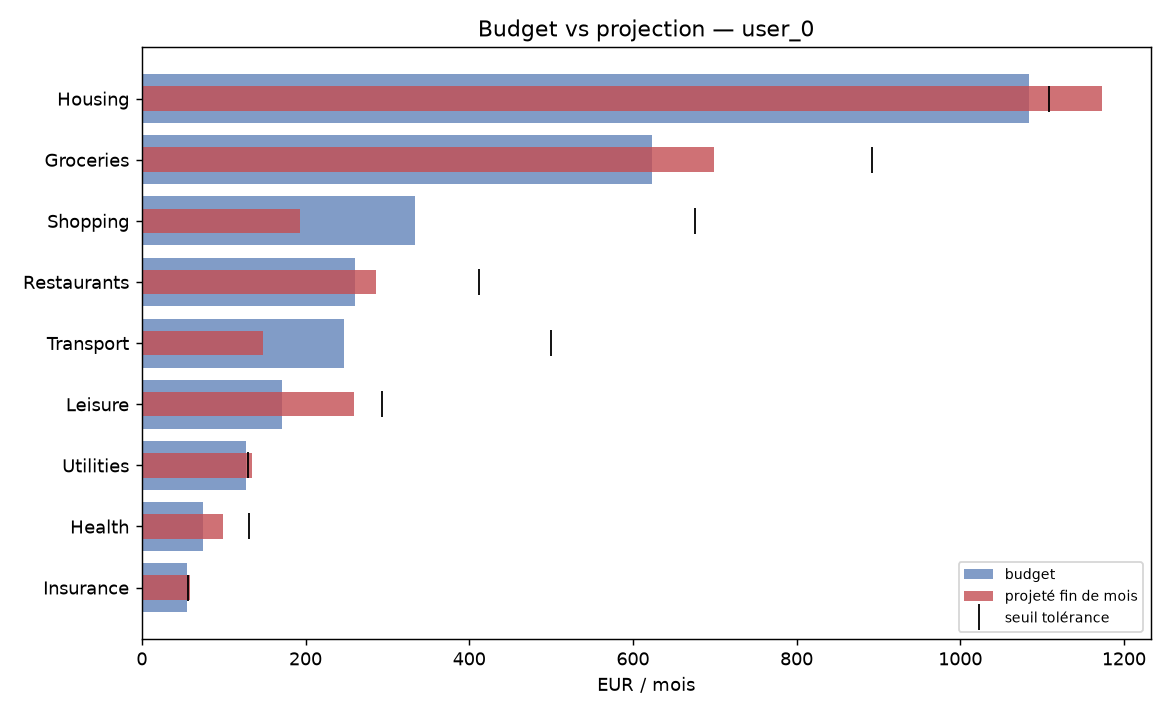

In [6]:
proj = pd.read_csv(ROOT / "reports" / "budget_projection.csv")
feed = pd.read_csv(ROOT / "reports" / "alert_feed.csv")
print("Catégories en dépassement projeté :")
display(proj[proj.breach].head(8)[["user", "category", "budget",
        "projected", "overshoot_pct"]].round(1))
print("Flux d'alertes (extrait) :")
display(feed.head(8))
display(Image(ROOT / "reports" / "figures" / "budget_vs_projection.png",
              width=680))

## 6. Limites & éthique

- **Données synthétiques** : les patterns et anomalies sont *générés* selon nos
  règles ; les performances (surtout la catégorisation quasi-parfaite) seraient
  plus basses sur de vraies données bancaires, plus bruitées et ambiguës. Le
  code est prêt à recevoir un vrai jeu (ex. *Daily Household Transactions*).
- **Vie privée** : les données financières sont sensibles ; un déploiement réel
  impose consentement, minimisation et traitement local/chiffré.
- **Faux positifs** : une alerte injustifiée érode la confiance ; le seuil doit
  être réglable par l'utilisateur, et les alertes explicables (ce que fournit le
  flux typé).
- **Personnalisation vs démarrage à froid** : un nouvel utilisateur sans
  historique ne peut pas être profilé — prévoir des budgets par défaut le temps
  d'accumuler des données.